In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("/content/time_series_covid19_confirmed_global.csv")

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289 entries, 0 to 288
Columns: 1147 entries, Province/State to 3/9/23
dtypes: float64(2), int64(1143), object(2)
memory usage: 2.5+ MB


In [4]:
print("Rows and Columns:", df.shape)

Rows and Columns: (289, 1147)


In [5]:
df.columns

Index(['Province/State', 'Country/Region', 'Lat', 'Long', '1/22/20', '1/23/20',
       '1/24/20', '1/25/20', '1/26/20', '1/27/20',
       ...
       '2/28/23', '3/1/23', '3/2/23', '3/3/23', '3/4/23', '3/5/23', '3/6/23',
       '3/7/23', '3/8/23', '3/9/23'],
      dtype='object', length=1147)

In [6]:
df.isnull().sum()

,0
Province/State,198
Country/Region,0
Lat,2
Long,2
1/22/20,0
...,...
3/5/23,0
3/6/23,0
3/7/23,0
3/8/23,0


In [7]:
df["Province/State"] = df["Province/State"].fillna("Unknown")

In [8]:
df = df.drop(["Lat", "Long"], axis=1)

In [9]:
country_df = df.groupby("Country/Region").sum()

country_df.head()

,Province/State,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
Country/Region,,,,,,,,,,,,,,,,,,,,,
Afghanistan,Unknown,0,0,0,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
Albania,Unknown,0,0,0,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
Algeria,Unknown,0,0,0,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
Andorra,Unknown,0,0,0,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
Angola,Unknown,0,0,0,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288


In [10]:
latest_cases = country_df.iloc[:, -1]

latest_cases.sort_values(ascending=False).head(10)

,3/9/23
Country/Region,
US,103802702
India,44690738
France,39866718
Germany,38249060
Brazil,37076053
Japan,33320438
"Korea, South",30615522
Italy,25603510
United Kingdom,24658705


/tmp/ipykernel_3815/2032368616.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


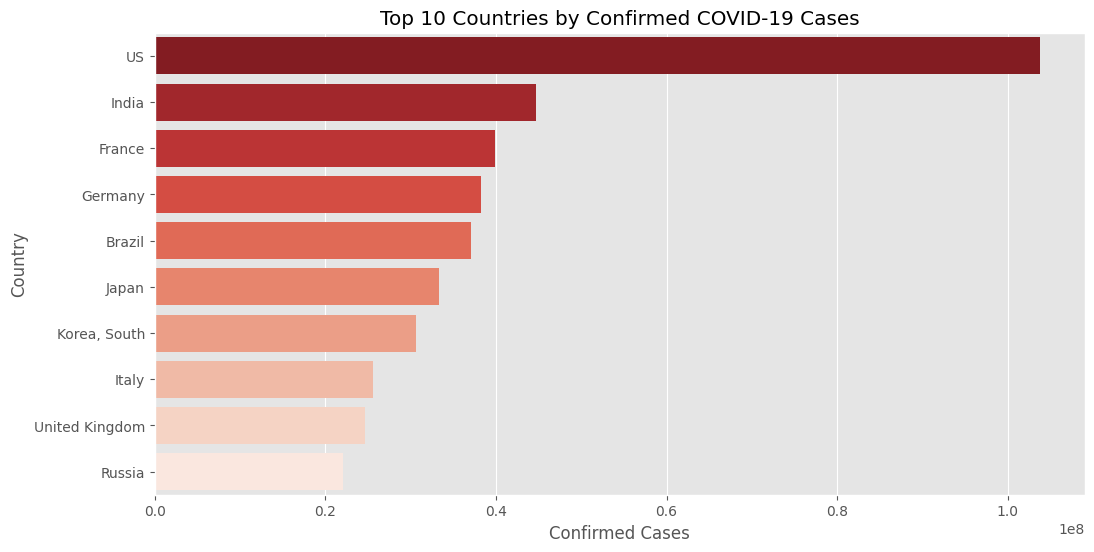

In [11]:
top10 = latest_cases.sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top10.values,
    y=top10.index,
    palette="Reds_r"
)

plt.title("Top 10 Countries by Confirmed COVID-19 Cases")
plt.xlabel("Confirmed Cases")
plt.ylabel("Country")

plt.show()


In [12]:
global_cases = country_df.sum()

trend = pd.DataFrame({
    "Date": global_cases.index,
    "Cases": global_cases.values
})

trend["Date"] = pd.to_datetime(trend["Date"])

trend.head()

/tmp/ipykernel_3815/3909796888.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  trend["Date"] = pd.to_datetime(trend["Date"])


DateParseError: Unknown datetime string format, unable to parse: Province/State, at position 0

In [13]:
country_df = df.groupby("Country/Region").sum(numeric_only=True)

In [14]:
print(country_df.columns[:10])

Index(['1/22/20', '1/23/20', '1/24/20', '1/25/20', '1/26/20', '1/27/20',
       '1/28/20', '1/29/20', '1/30/20', '1/31/20'],
      dtype='object')


In [15]:
global_cases = country_df.sum()

trend = global_cases.reset_index()
trend.columns = ["Date", "Cases"]

trend["Date"] = pd.to_datetime(trend["Date"], format="%m/%d/%y")

trend.head()

,Date,Cases
0,2020-01-22,557
1,2020-01-23,657
2,2020-01-24,944
3,2020-01-25,1437
4,2020-01-26,2120


In [16]:
global_cases = country_df.sum()

trend = global_cases.reset_index()
trend.columns = ["Date", "Cases"]

trend["Date"] = pd.to_datetime(trend["Date"], format="%m/%d/%y")

trend.head()

,Date,Cases
0,2020-01-22,557
1,2020-01-23,657
2,2020-01-24,944
3,2020-01-25,1437
4,2020-01-26,2120


In [17]:
plt.figure(figsize=(15,6))

plt.plot(trend["Date"], trend["Daily Increase"], color="red", linewidth=2)

plt.title("Daily Increase in Global COVID-19 Cases", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Daily Increase")
plt.xticks(rotation=45)

plt.grid(True)
plt.show()

KeyError: 'Daily Increase'

<Figure size 1500x600 with 0 Axes>

In [18]:
trend.head()

,Date,Cases
0,2020-01-22,557
1,2020-01-23,657
2,2020-01-24,944
3,2020-01-25,1437
4,2020-01-26,2120


In [19]:
plt.figure(figsize=(15,6))

plt.plot(trend["Date"], trend["Daily Increase"], color="red", linewidth=2)

plt.title("Daily Increase in Global COVID-19 Cases")
plt.xlabel("Date")
plt.ylabel("Daily Increase")
plt.xticks(rotation=45)

plt.grid(True)
plt.show()

KeyError: 'Daily Increase'

<Figure size 1500x600 with 0 Axes>

In [20]:
print(trend.columns)

Index(['Date', 'Cases'], dtype='object')


In [21]:
trend["Daily Increase"] = trend["Cases"].diff()

print(trend.columns)
trend.head()

Index(['Date', 'Cases', 'Daily Increase'], dtype='object')


,Date,Cases,Daily Increase
0,2020-01-22,557,NaN
1,2020-01-23,657,100.0
2,2020-01-24,944,287.0
3,2020-01-25,1437,493.0
4,2020-01-26,2120,683.0


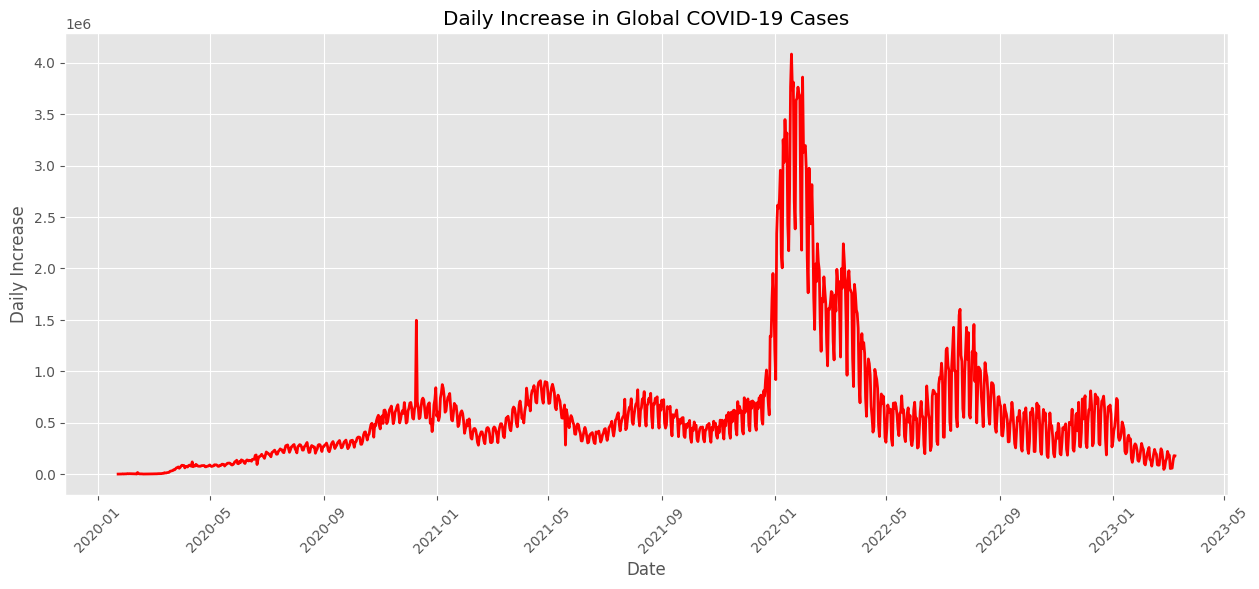

In [22]:
plt.figure(figsize=(15,6))

plt.plot(trend["Date"], trend["Daily Increase"],
         color="red",
         linewidth=2)

plt.title("Daily Increase in Global COVID-19 Cases")
plt.xlabel("Date")
plt.ylabel("Daily Increase")
plt.xticks(rotation=45)

plt.grid(True)

plt.show()

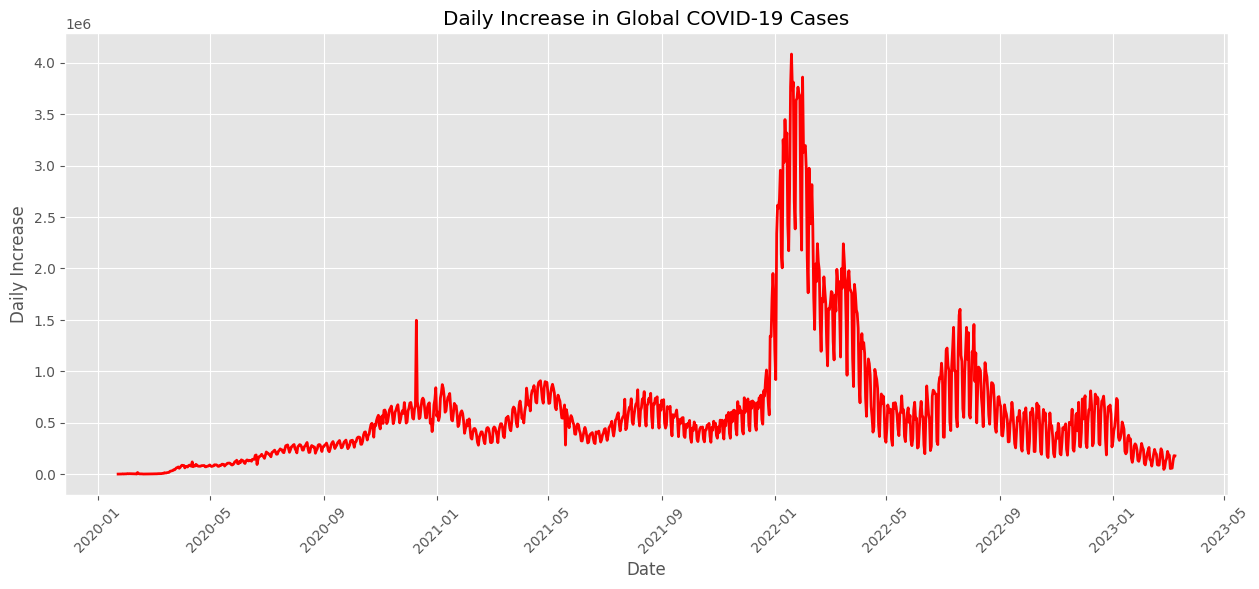

In [23]:
plt.figure(figsize=(15,6))

plt.plot(trend["Date"], trend["Daily Increase"],
         color="red",
         linewidth=2)

plt.title("Daily Increase in Global COVID-19 Cases")
plt.xlabel("Date")
plt.ylabel("Daily Increase")
plt.xticks(rotation=45)

plt.grid(True)

plt.show()

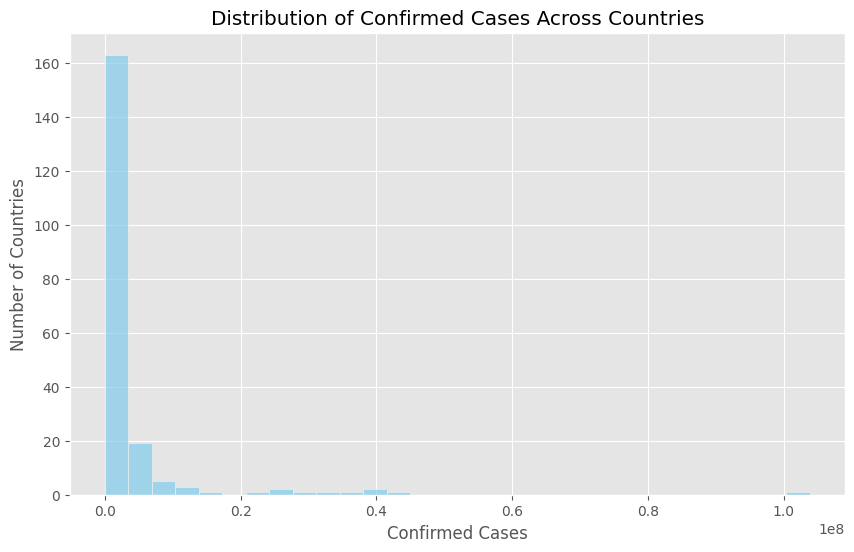

In [24]:
plt.figure(figsize=(10,6))

sns.histplot(latest_cases, bins=30, color="skyblue")

plt.title("Distribution of Confirmed Cases Across Countries")
plt.xlabel("Confirmed Cases")
plt.ylabel("Number of Countries")

plt.show()

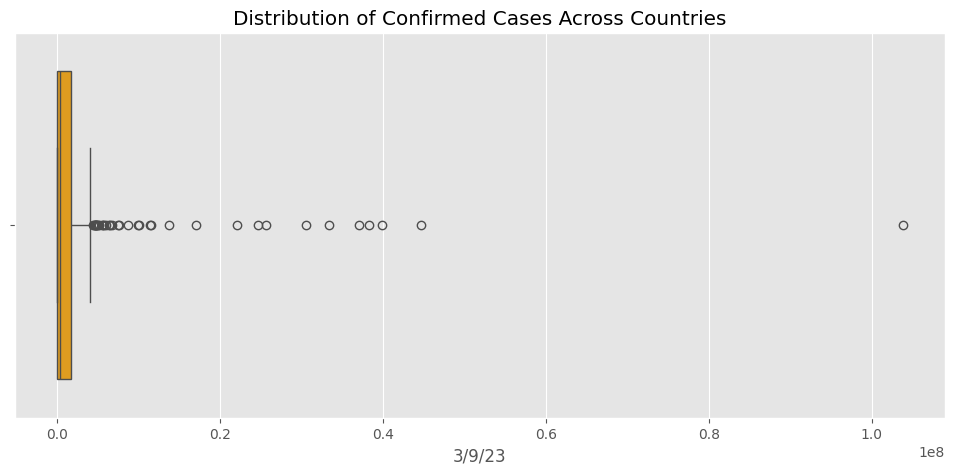

In [25]:
plt.figure(figsize=(12,5))

sns.boxplot(x=latest_cases, color="orange")

plt.title("Distribution of Confirmed Cases Across Countries")

plt.show()


In [28]:
heatmap_data = country_df.loc[top20.index]

plt.figure(figsize=(18,8))

sns.heatmap(
    heatmap_data.iloc[:, -30:],
    cmap="Reds",
    linewidths=0.3
)

plt.title("COVID-19 Cases - Last 30 Days (Top 20 Countries)")
plt.xlabel("Date")
plt.ylabel("Country")

plt.show()


NameError: name 'top20' is not defined

In [29]:
top20 = latest_cases.sort_values(ascending=False).head(20)

top20

,3/9/23
Country/Region,
US,103802702
India,44690738
France,39866718
Germany,38249060
Brazil,37076053
Japan,33320438
"Korea, South",30615522
Italy,25603510
United Kingdom,24658705


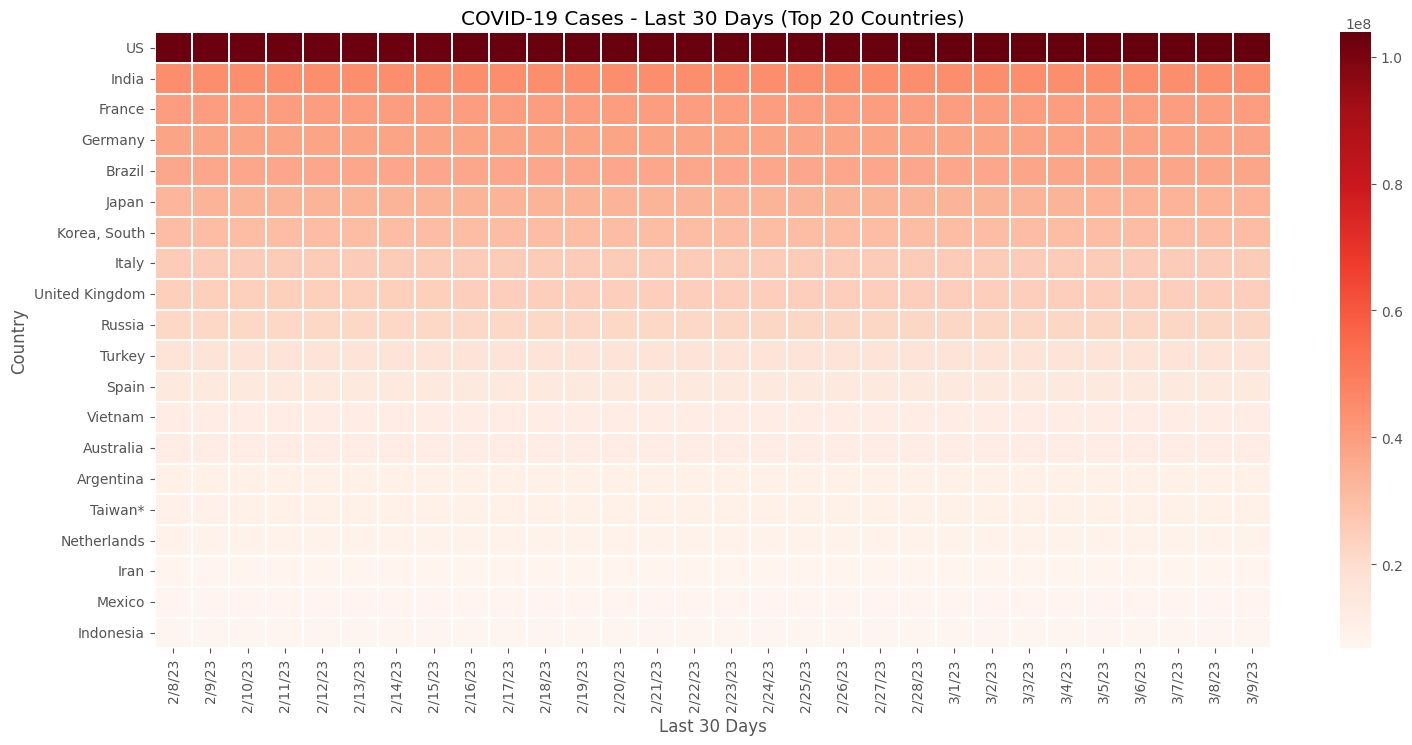

In [30]:
heatmap_data = country_df.loc[top20.index]

plt.figure(figsize=(18,8))

sns.heatmap(
    heatmap_data.iloc[:, -30:],
    cmap="Reds",
    linewidths=0.3
)

plt.title("COVID-19 Cases - Last 30 Days (Top 20 Countries)")
plt.xlabel("Last 30 Days")
plt.ylabel("Country")

plt.show()

In [31]:
print("Total Countries:", len(latest_cases))
print("Highest Cases:", latest_cases.max())
print("Country with Highest Cases:", latest_cases.idxmax())
print("Average Cases:", round(latest_cases.mean(), 2))
print("Median Cases:", latest_cases.median())

Total Countries: 201
Highest Cases: 103802702
Country with Highest Cases: US
Average Cases: 3366020.64
Median Cases: 317367.0


In [32]:
top10_df = latest_cases.sort_values(ascending=False).head(10).reset_index()
top10_df.columns = ["Country", "Confirmed Cases"]

top10_df

,Country,Confirmed Cases
0,US,103802702
1,India,44690738
2,France,39866718
3,Germany,38249060
4,Brazil,37076053
5,Japan,33320438
6,"Korea, South",30615522
7,Italy,25603510
8,United Kingdom,24658705
9,Russia,22075858


In [33]:
trend.to_csv("global_covid_trend.csv", index=False)
top10_df.to_csv("top10_countries.csv", index=False)

print("Files saved successfully!")

Files saved successfully!
